Riemann zeta fonksiyonunun ilk 10 sıfırı yükleniyor...
Sıfır değerleri (imajiner kısımlar):
1. sıfır: t = 14.1347
2. sıfır: t = 21.0220
3. sıfır: t = 25.0109
4. sıfır: t = 30.4249
5. sıfır: t = 32.9351
6. sıfır: t = 37.5862
7. sıfır: t = 40.9187
8. sıfır: t = 43.3271
9. sıfır: t = 48.0052
10. sıfır: t = 49.7738

Kritik doğru üzerinde zeta fonksiyonu hesaplanıyor...


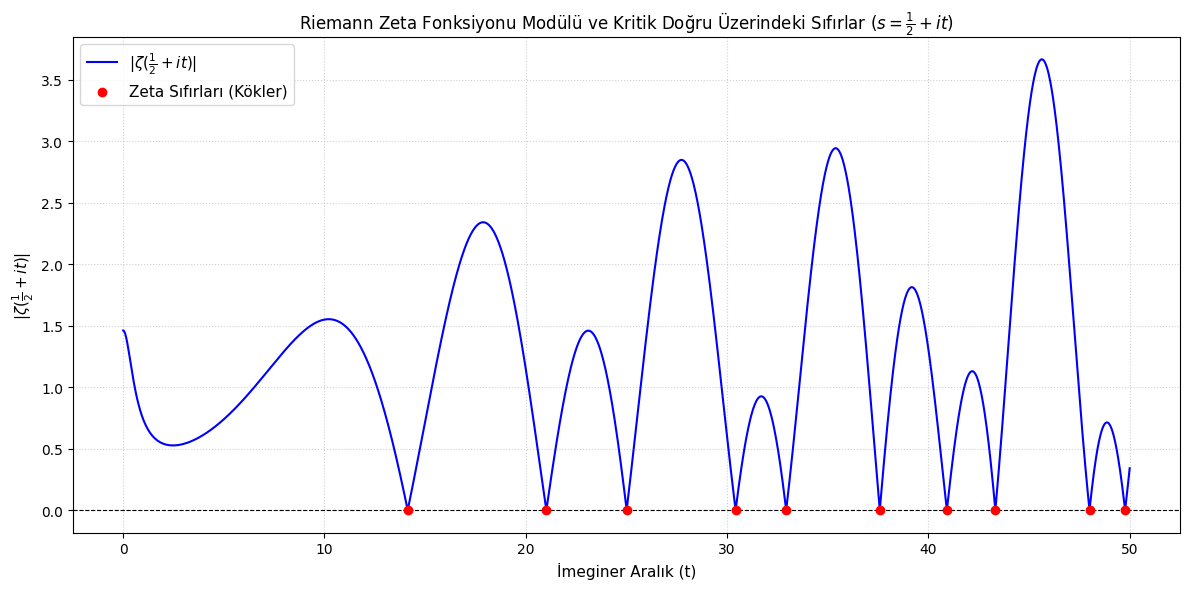

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpmath import zetazero, zeta

# 1. İlk bilinen bazı Riemann zeta sıfırlarını alalım (Örn: İlk 10 sıfır)
# Not: 1 milyon sıfırın tamamını bellekte anlık çizdirmek ve hesaplamak 
# devasa bir altyapı (C++/Fortran tabanlı özel kütüphaneler) gerektirir.
num_zeros = 10
print(f"Riemann zeta fonksiyonunun ilk {num_zeros} sıfırı yükleniyor...")
zeros = [float(zetazero(n).imag) for n in range(1, num_zeros + 1)]

print("Sıfır değerleri (imajiner kısımlar):")
for i, z in enumerate(zeros, 1):
    print(f"{i}. sıfır: t = {z:.4f}")

# 2. Kritik doğru üzerinde (s = 1/2 + it) zeta fonksiyonunun büyüklüğünü görselleştirme
# t parametresini ilk sıfırları kapsayacak şekilde geniş bir aralıkta seçiyoruz.
t_vals = np.linspace(0, 50, 2000)
zeta_vals = []

print("\nKritik doğru üzerinde zeta fonksiyonu hesaplanıyor...")
for t in t_vals:
    # s = 0.5 + i*t
    s = 0.5 + 1j * t
    # Zeta fonksiyonunun mutlak değerini hesapla
    zeta_vals.append(float(abs(zeta(s))))

# 3. Grafik Çizimi
plt.figure(figsize=(12, 6))
plt.plot(t_vals, zeta_vals, label=r"$|\zeta(\frac{1}{2} + it)|$", color="blue", linewidth=1.5)

# Sıfır noktalarını grafik üzerinde işaretleme
zero_heights = [0] * len(zeros)
plt.scatter(zeros, zero_heights, color="red", zorder=5, label="Zeta Sıfırları (Kökler)")

plt.title(r"Riemann Zeta Fonksiyonu Modülü ve Kritik Doğru Üzerindeki Sıfırlar ($s = \frac{1}{2} + it$)", fontsize=12)
plt.xlabel("İmeginer Aralık (t)", fontsize=11)
plt.ylabel(r"$|\zeta(\frac{1}{2} + it)|$", fontsize=11)
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

# Grafiği göster
plt.show()

Riemann zeta fonksiyonu 3D değerleri hesaplanıyor...


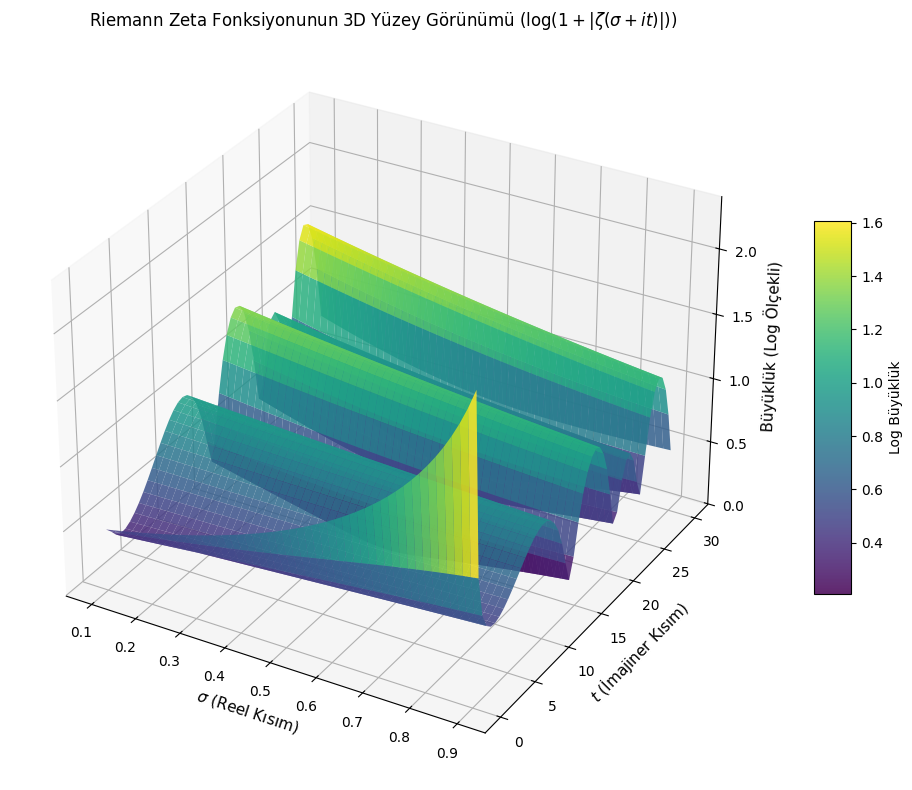

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpmath import zeta
import numpy as np

# 1. Grid (Izgara) Tanımlama
# s = sigma + i*t (Kritik şerit etrafında bir bölge seçiyoruz)
sigma = np.linspace(0.1, 0.9, 50)
t = np.linspace(0, 30, 50)
sigma_grid, t_grid = np.meshgrid(sigma, t)

# 2. Zeta Değerlerini Hesaplama
z_vals = np.zeros(sigma_grid.shape)
print("Riemann zeta fonksiyonu 3D değerleri hesaplanıyor...")

for i in range(sigma_grid.shape[0]):
  for j in range(sigma_grid.shape[1]):
    s = complex(sigma_grid[i, j], t_grid[i, j])
    # Fonksiyonun büyüklüğünü alıyoruz. 
    # Aşırı büyük değerleri dengelemek için logaritmik dönüşüm kullanıyoruz.
    val = float(abs(zeta(s)))
    z_vals[i, j] = np.log1p(val)

# 3. 3D Grafik Çizimi
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    sigma_grid,
    t_grid,
    z_vals,
    cmap="viridis",
    edgecolor="none",
    alpha=0.85,
)

# Grafik Etiketleri ve Düzenlemeler
ax.set_title(
    r"Riemann Zeta Fonksiyonunun 3D Yüzey Görünümü ($\log(1 + |\zeta(\sigma +"
    r" it)|)$)",
    fontsize=12,
)
ax.set_xlabel(r"$\sigma$ (Reel Kısım)", fontsize=11)
ax.set_ylabel(r"$t$ (İmajiner Kısım)", fontsize=11)
ax.set_zlabel("Büyüklük (Log Ölçekli)", fontsize=11)

# Renk skalası ekleme
fig.colorbar(surf, shrink=0.5, aspect=10, label="Log Büyüklük")

plt.tight_layout()
plt.show()